In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd

df = pd.read_csv("data/SPX_data_26.02.24.csv")


In [3]:
df.head(5)

,underlying_symbol,quote_datetime,root,expiration,strike,option_type,open,high,low,close,trade_volume,bid_size,bid,ask_size,ask,underlying_bid,underlying_ask,open_interest,time_to_maturity
0,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,200.0,C,0.0,0.0,0.0,0.0,0,2,6673.0,1,6692.9,6852.66,6913.22,35,0.063014
1,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,400.0,C,0.0,0.0,0.0,0.0,0,1,6473.3,1,6492.5,6852.66,6913.22,13,0.063014
2,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,600.0,C,0.0,0.0,0.0,0.0,0,1,6273.5,1,6294.5,6852.66,6913.22,6,0.063014
3,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,800.0,C,0.0,0.0,0.0,0.0,0,2,6074.7,1,6093.2,6852.66,6913.22,9,0.063014
4,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,1000.0,C,0.0,0.0,0.0,0.0,0,10,5877.8,10,5892.1,6852.66,6913.22,1101,0.063014


Volatility smile & term structure

In [4]:
from src.black_scholes import implied_volatility

df['C_mkt'] = (df['bid'] + df['ask']) / 2
df['S_0'] = (df['underlying_bid'] + df['underlying_ask']) / 2
r_annual = 0  # Assunzione tasso d'interesse (4.5%)

df_calls = df

# 3. Calcolo dell'IV su tutto il dataset
df_calls['implied_vol'] = df_calls.apply(
    lambda row: implied_volatility(row['C_mkt'], row['S_0'], row['strike'], row['time_to_maturity'], r_annual),
    axis=1
)

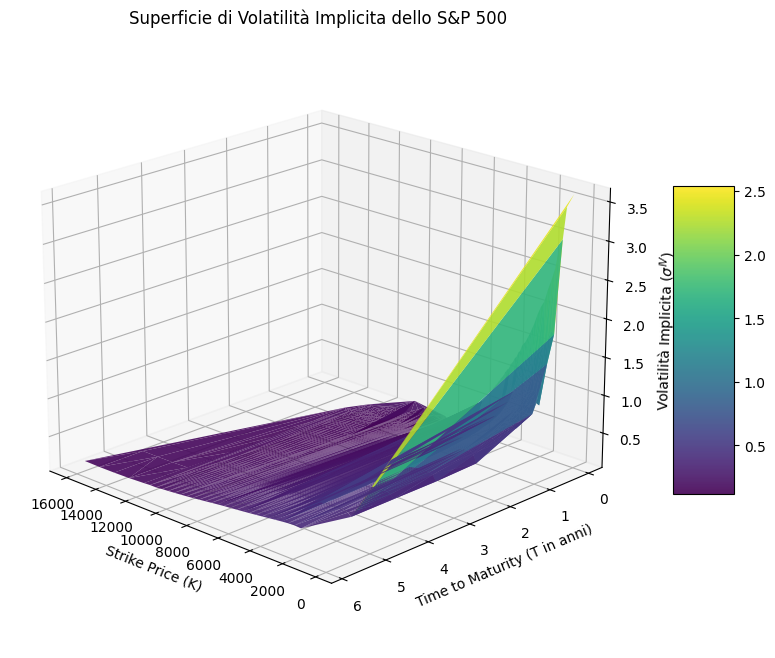

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Applica prima i filtri di pulizia (bid > 0, ask > 0, spread sensato)
df_clean = df_calls[(df_calls['bid'] > 0) & (df_calls['ask'] > 0)].copy()
df_clean['IV'] = df_clean['implied_vol'] # la colonna calcolata
df_clean = df_clean.dropna(subset=['IV'])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Creiamo la superficie tridimensionale
surf = ax.plot_trisurf(df_clean['strike'], df_clean['time_to_maturity'], df_clean['IV'], 
                       cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Time to Maturity (T in anni)')
ax.set_zlabel('Volatilità Implicita ($\sigma^{IV}$)')
ax.set_title('Superficie di Volatilità Implicita dello S&P 500')

# Aggiunge la barra dei colori
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
ax.view_init(elev=20, azim=134) # Ruota per vedere bene lo skew

plt.show()

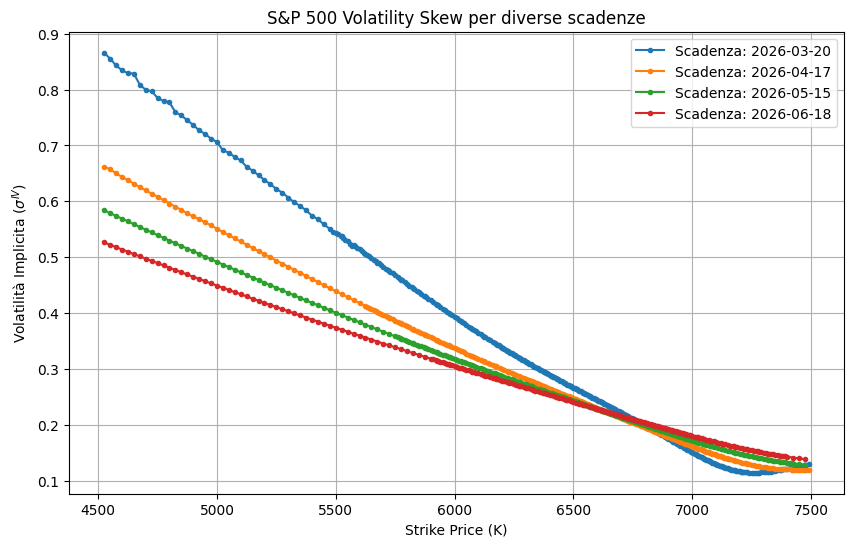

In [6]:
plt.figure(figsize=(10, 6))

# Prendiamo le scadenze uniche disponibili e ne scegliamo alcune significative
scadenze_uniche = sorted(df_clean['expiration'].unique())

for scadenza in scadenze_uniche[:4]: # Mostriamo le prime 4 scadenze come esempio
    df_sub = df_clean[df_clean['expiration'] == scadenza].sort_values(by='strike')
    
    # Visualizziamo solo la zona centrale (ATM) per evitare rumore dagli estremi
    df_sub = df_sub[(df_sub['strike'] > 4500) & (df_sub['strike'] < 7500)]
    
    plt.plot(df_sub['strike'], df_sub['IV'], label=f'Scadenza: {scadenza}', marker='o', markersize=3)

plt.title('S&P 500 Volatility Skew per diverse scadenze')
plt.xlabel('Strike Price (K)')
plt.ylabel('Volatilità Implicita ($\sigma^{IV}$)')
plt.grid(True)
plt.legend()
plt.show()

### Part 2: Heston model

In [7]:
import numpy as np
import pandas as pd
import src.heston as hst
from tqdm import tqdm  # <--- IMPORTA QUESTO

N_SAMPLES = 20000
S0_mercato = 6852.66  
tasso_risk_free = 0.045

dataset_rows = []

print("Generazione del dataset sintetico in corso...")

# Avvolgi il range dentro tqdm()
for i in tqdm(range(N_SAMPLES), desc="Progresso Integrali"):
    kappa_casuale = np.random.uniform(0.1, 5.0)
    theta_casuale = np.random.uniform(0.01, 0.25)
    xi_casuale = np.random.uniform(0.05, 1.0)
    rho_casuale = np.random.uniform(-0.95, 0.0)
    V0_casuale = np.random.uniform(0.01, 0.25)
    
    maturity_casuale = np.random.uniform(0.1, 3.0) # Partiamo da 0.1 per stabilità
    moneyness = np.random.uniform(0.8, 1.2)
    strike_casuale = S0_mercato * moneyness
    
    try:
        prezzo_sintetico = hst.heston_call_price(
            S0=S0_mercato, 
            K=strike_casuale, 
            T=maturity_casuale, 
            r=tasso_risk_free, 
            kappa=kappa_casuale, 
            theta=theta_casuale, 
            xi=xi_casuale, 
            rho=rho_casuale, 
            V0=V0_casuale
        )
        dataset_rows.append([kappa_casuale, theta_casuale, xi_casuale, rho_casuale, V0_casuale, strike_casuale, maturity_casuale, prezzo_sintetico])
    except:
        continue

columns = ['kappa', 'theta', 'xi', 'rho', 'V0', 'strike', 'time_to_maturity', 'target_price']
df_sintetico = pd.DataFrame(dataset_rows, columns=columns)
print(f"\nGenerazione completata! Righe totali: {len(df_sintetico)}")

Generazione del dataset sintetico in corso...


Progresso Integrali: 100%|██████████| 20000/20000 [06:38<00:00, 50.21it/s]



Generazione completata! Righe totali: 20000


In [ ]:
df_sintetico.to_csv('data/heston_synthetic_dataset.csv', index=False)

print(f"\nGenerazione completata e salvata con successo in 'data/heston_synthetic_dataset.csv'! Righe totali: {len(df_sintetico)}")


Generazione completata e salvata con successo in 'heston_synthetic_dataset.csv'! Righe totali: 20000


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

def bs_call_price(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return np.maximum(0.0, S - K * np.exp(-r * T))
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def calculate_iv_row(row, S, r):
    K = row['strike']
    T = row['time_to_maturity']
    target = row['target_price']
    
    intrinsic_value = max(0.0, S - K * np.exp(-r * T))
    if target <= intrinsic_value or target >= S:
        return np.nan
        
    obj_fun = lambda sigma: bs_call_price(S, K, T, r, sigma) - target
    try:
        return brentq(obj_fun, 1e-5, 5.0)
    except ValueError:
        return np.nan

def main():
    S0_mercato = 6852.66
    tasso_risk_free = 0.045
    
    # Sostituire con il percorso reale del proprio file
    csv_filename = 'data/heston_synthetic_dataset.csv' 
    
    try:
        df = pd.read_csv(csv_filename)
    except FileNotFoundError:
        print(f"Errore: il file '{csv_filename}' non è stato trovato.")
        return

    # 1. Calcolo preliminare della Implied Volatility
    df['implied_vol'] = df.apply(lambda row: calculate_iv_row(row, S0_mercato, tasso_risk_free), axis=1)
    df_clean = df.dropna(subset=['implied_vol'])
    
if __name__ == "main":
    main()

In [10]:
df

,underlying_symbol,quote_datetime,root,expiration,strike,option_type,open,high,low,close,...,bid,ask_size,ask,underlying_bid,underlying_ask,open_interest,time_to_maturity,C_mkt,S_0,implied_vol
0,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,200.0,C,0.0,0.0,0.00,0.00,...,6673.0,1,6692.9,6852.66,6913.22,35,0.063014,6682.95,6882.94,3.599856
1,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,400.0,C,0.0,0.0,0.00,0.00,...,6473.3,1,6492.5,6852.66,6913.22,13,0.063014,6482.90,6882.94,NaN
2,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,600.0,C,0.0,0.0,0.00,0.00,...,6273.5,1,6294.5,6852.66,6913.22,6,0.063014,6284.00,6882.94,3.418470
3,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,800.0,C,0.0,0.0,0.00,0.00,...,6074.7,1,6093.2,6852.66,6913.22,9,0.063014,6083.95,6882.94,2.991578
4,^SPX,2026-02-24 16:15:00,SPX,2026-03-20,1000.0,C,0.0,0.0,0.00,0.00,...,5877.8,10,5892.1,6852.66,6913.22,1101,0.063014,5884.95,6882.94,2.865481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,^SPX,2026-02-24 16:15:00,SPX,2031-12-19,12000.0,C,0.0,0.0,0.00,0.00,...,174.9,28,249.0,6852.66,6913.22,832,5.816438,211.95,6882.94,0.187152
4273,^SPX,2026-02-24 16:15:00,SPX,2031-12-19,13000.0,C,0.0,0.0,0.00,0.00,...,87.4,42,147.9,6852.66,6913.22,85,5.816438,117.65,6882.94,0.176476
4274,^SPX,2026-02-24 16:15:00,SPX,2031-12-19,14000.0,C,0.0,0.0,0.00,0.00,...,47.0,57,94.0,6852.66,6913.22,0,5.816438,70.50,6882.94,0.171661
4275,^SPX,2026-02-24 16:15:00,SPX,2031-12-19,15000.0,C,43.7,45.9,43.70,45.90,...,43.7,10,47.5,6852.66,6913.22,0,5.816438,45.60,6882.94,0.170188


In [11]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def bs_price_vega(S, K, T, r, sigma, option_type):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    vega = S * np.sqrt(T) * norm.pdf(d1)
    
    if option_type == 'C':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        
    return price, vega

def implied_volatility(target_price, S, K, T, r, option_type, max_iter=100, tol=1e-6):
    sigma = 0.20  # inizializzazione standard al 20%
    for _ in range(max_iter):
        price, vega = bs_price_vega(S, K, T, r, sigma, option_type)
        diff = price - target_price
        if abs(diff) < tol:
            return sigma
        if vega < 1e-6:
            break
        sigma -= diff / vega
    return np.nan

# Caricamento e preparazione dati classici
df = pd.read_csv('data/SPX_data_26.02.24.csv')
df['S'] = (df['underlying_bid'] + df['underlying_ask']) / 2
df['P_mkt'] = (df['bid'] + df['ask']) / 2

r = 0.045  # tasso risk-free costante

df['IV'] = df.apply(
    lambda row: implied_volatility(
        target_price=row['P_mkt'],
        S=row['S'],
        K=row['strike'],
        T=row['time_to_maturity'],
        r=r,
        option_type=row['option_type']
    ), axis=1
)

print(df[['expiration', 'strike', 'option_type', 'IV']].dropna().head())

     expiration  strike option_type        IV
111  2026-03-20  5670.0           C  0.365176
112  2026-03-20  5675.0           C  0.363524
113  2026-03-20  5680.0           C  0.363457
114  2026-03-20  5690.0           C  0.360157
115  2026-03-20  5700.0           C  0.359180


In [12]:
df.to_csv('data/SPX_data_with_IV.csv', index=False)

In [ ]:
import pandas as pd

# Caricamento del dataset con le IV
df_iv = pd.read_csv('data/SPX_data_with_IV.csv')

# Rimozione delle righe dove la colonna IV è NaN
df_clean = df_iv.dropna(subset=['IV'])

# Salvataggio del dataset pulito
df_clean.to_csv('data/SPX_data_clean_IV.csv', index=False)

# Visualizzazione delle prime righe e del conteggio residuo
print(f"Righe rimosse: {len(df_iv) - len(df_clean)}")
print(f"Righe rimanenti: {len(df_clean)}")
print(df_clean[['expiration', 'strike', 'option_type', 'IV']].head())

Righe rimosse: 1113
Righe rimanenti: 3164
     expiration  strike option_type        IV
111  2026-03-20  5670.0           C  0.365176
112  2026-03-20  5675.0           C  0.363524
113  2026-03-20  5680.0           C  0.363457
114  2026-03-20  5690.0           C  0.360157
115  2026-03-20  5700.0           C  0.359180


: 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Preparazione dei dati
# Carichiamo direttamente il dataset pulito SPX salvato in precedenza
df_clean = pd.read_csv('data/SPX_data_clean_IV.csv')
df_nn = df_clean.copy()
df_nn['option_type_numeric'] = df_nn['option_type'].map({'C': 1, 'P': 0})

# Input features: strike, time_to_maturity, S, option_type_numeric
X = df_nn[['strike', 'time_to_maturity', 'S', 'option_type_numeric']].values
y = df_nn['IV'].values.reshape(-1, 1)

# Divisione in train (80%) e test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizzazione delle feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Definizione delle funzioni di attivazione in NumPy
def softplus(x):
    # Versione numericamente stabile di softplus: log(1 + exp(x))
    return np.log1p(np.exp(np.minimum(x, 20))) + np.maximum(0, x - 20)

def sigmoid(x):
    # Funzione sigmoidea (derivata del softplus)
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# 3. Classe per la Rete Neurale (MLP) a 4 layer densi
class NumPyMLP:
    def __init__(self, input_dim):
        np.random.seed(42)
        # Definizione dell'architettura a 4 layer lineari:
        # Layer 1: input_dim -> 128
        # Layer 2: 128 -> 64
        # Layer 3: 64 -> 32
        # Layer 4: 32 -> 1 (regressione lineare)
        self.W1 = np.random.randn(input_dim, 128) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, 128))
        
        self.W2 = np.random.randn(128, 64) * np.sqrt(2.0 / 128)
        self.b2 = np.zeros((1, 64))
        
        self.W3 = np.random.randn(64, 32) * np.sqrt(2.0 / 64)
        self.b3 = np.zeros((1, 32))
        
        self.W4 = np.random.randn(32, 1) * np.sqrt(2.0 / 32)
        self.b4 = np.zeros((1, 1))
        
        # Parametri dell'ottimizzatore Adam
        self.m_W1, self.v_W1 = np.zeros_like(self.W1), np.zeros_like(self.W1)
        self.m_b1, self.v_b1 = np.zeros_like(self.b1), np.zeros_like(self.b1)
        self.m_W2, self.v_W2 = np.zeros_like(self.W2), np.zeros_like(self.W2)
        self.m_b2, self.v_b2 = np.zeros_like(self.b2), np.zeros_like(self.b2)
        self.m_W3, self.v_W3 = np.zeros_like(self.W3), np.zeros_like(self.W3)
        self.m_b3, self.v_b3 = np.zeros_like(self.b3), np.zeros_like(self.b3)
        self.m_W4, self.v_W4 = np.zeros_like(self.W4), np.zeros_like(self.W4)
        self.m_b4, self.v_b4 = np.zeros_like(self.b4), np.zeros_like(self.b4)
        self.t = 0

    def forward(self, X):
        self.X = X
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = softplus(self.z1)
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = softplus(self.z2)
        
        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = softplus(self.z3)
        
        self.z4 = np.dot(self.a3, self.W4) + self.b4
        return self.z4

    def backward(self, y_pred, y_true):
        N = y_true.shape[0]
        dz4 = (y_pred - y_true) / N
        dW4 = np.dot(self.a3.T, dz4)
        db4 = np.sum(dz4, axis=0, keepdims=True)
        
        da3 = np.dot(dz4, self.W4.T)
        dz3 = da3 * sigmoid(self.z3)
        dW3 = np.dot(self.a2.T, dz3)
        db3 = np.sum(dz3, axis=0, keepdims=True)
        
        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * sigmoid(self.z2)
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * sigmoid(self.z1)
        dW1 = np.dot(self.X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        
        return dW1, db1, dW2, db2, dW3, db3, dW4, db4

    def step(self, grads, lr=0.005, beta1=0.9, beta2=0.999, eps=1e-8):
        dW1, db1, dW2, db2, dW3, db3, dW4, db4 = grads
        self.t += 1
        
        # Aggiornamento parametri con ottimizzatore Adam
        # Layer 1
        self.m_W1 = beta1 * self.m_W1 + (1 - beta1) * dW1
        self.v_W1 = beta2 * self.v_W1 + (1 - beta2) * (dW1**2)
        self.W1 -= lr * (self.m_W1 / (1 - beta1**self.t)) / (np.sqrt(self.v_W1 / (1 - beta2**self.t)) + eps)
        
        self.m_b1 = beta1 * self.m_b1 + (1 - beta1) * db1
        self.v_b1 = beta2 * self.v_b1 + (1 - beta2) * (db1**2)
        self.b1 -= lr * (self.m_b1 / (1 - beta1**self.t)) / (np.sqrt(self.v_b1 / (1 - beta2**self.t)) + eps)
        
        # Layer 2
        self.m_W2 = beta1 * self.m_W2 + (1 - beta1) * dW2
        self.v_W2 = beta2 * self.v_W2 + (1 - beta2) * (dW2**2)
        self.W2 -= lr * (self.m_W2 / (1 - beta1**self.t)) / (np.sqrt(self.v_W2 / (1 - beta2**self.t)) + eps)
        
        self.m_b2 = beta1 * self.m_b2 + (1 - beta1) * db2
        self.v_b2 = beta2 * self.v_b2 + (1 - beta2) * (db2**2)
        self.b2 -= lr * (self.m_b2 / (1 - beta1**self.t)) / (np.sqrt(self.v_b2 / (1 - beta2**self.t)) + eps)
        
        # Layer 3
        self.m_W3 = beta1 * self.m_W3 + (1 - beta1) * dW3
        self.v_W3 = beta2 * self.v_W3 + (1 - beta2) * (dW3**2)
        self.W3 -= lr * (self.m_W3 / (1 - beta1**self.t)) / (np.sqrt(self.v_W3 / (1 - beta2**self.t)) + eps)
        
        self.m_b3 = beta1 * self.m_b3 + (1 - beta1) * db3
        self.v_b3 = beta2 * self.v_b3 + (1 - beta2) * (db3**2)
        self.b3 -= lr * (self.m_b3 / (1 - beta1**self.t)) / (np.sqrt(self.v_b3 / (1 - beta2**self.t)) + eps)
        
        # Layer 4
        self.m_W4 = beta1 * self.m_W4 + (1 - beta1) * dW4
        self.v_W4 = beta2 * self.v_W4 + (1 - beta2) * (dW4**2)
        self.W4 -= lr * (self.m_W4 / (1 - beta1**self.t)) / (np.sqrt(self.v_W4 / (1 - beta2**self.t)) + eps)
        
        self.m_b4 = beta1 * self.m_b4 + (1 - beta1) * db4
        self.v_b4 = beta2 * self.v_b4 + (1 - beta2) * (db4**2)
        self.b4 -= lr * (self.m_b4 / (1 - beta1**self.t)) / (np.sqrt(self.v_b4 / (1 - beta2**self.t)) + eps)

# 4. Ciclo di addestramento
model = NumPyMLP(input_dim=X_train.shape[1])
epochs = 800
train_losses = []
test_losses = []

print("Inizio addestramento della rete neurale in NumPy...")
for epoch in range(epochs):
    # Passaggio in avanti
    y_pred = model.forward(X_train_scaled)
    loss = np.mean((y_pred - y_train) ** 2)
    train_losses.append(loss)
    
    # Calcolo dei gradienti
    grads = model.backward(y_pred, y_train)
    # Aggiornamento dei pesi (Adam)
    model.step(grads, lr=0.005)
    
    # Valutazione sul test set
    y_test_pred = model.forward(X_test_scaled)
    test_loss = np.mean((y_test_pred - y_test) ** 2)
    test_losses.append(test_loss)
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoca {epoch+1:03d}/{epochs} | Loss Train (MSE): {loss:.6f} | Loss Test (MSE): {test_loss:.6f}")

# 5. Grafico dell'andamento della Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train MSE')
plt.plot(test_losses, label='Test MSE')
plt.title('Curva di Loss (MSE) - Rete NumPy')
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

# 6. Predizioni finali e confronto
final_preds = model.forward(X_test_scaled).flatten()
comparison = pd.DataFrame({
    'Strike': X_test[:, 0],
    'Time to Maturity': X_test[:, 1],
    'Option Type': np.where(X_test[:, 3] == 1, 'C', 'P'),
    'IV Reale': y_test.flatten(),
    'IV Predetta': final_preds
})
print("\nEsempio di predizioni sul Test Set:")
print(comparison.head(10))
